# Question 6 — Audio Transcription Using Full and Quantized Open-Source Models

## Complete Google Colab Assignment

**Model:** `openai/whisper-small`  
**Dataset:** `sanchit-gandhi/librispeech_asr_dummy`  
**Comparison:** FP32 vs Dynamic INT8  
**Metrics:** WER, CER, inference time, model size, transcription errors

### Objective
Build an audio transcription pipeline using an open-source Hugging Face speech model and compare a full-precision model with a quantized version.

Whisper Small is an open-source ASR model available on Hugging Face. The selected LibriSpeech dummy dataset contains audio and reference text, making it suitable for WER/CER evaluation.

## 1. Model Description

### Whisper Small

Whisper is an automatic speech recognition model based on an encoder-decoder Transformer architecture. The Hugging Face `openai/whisper-small` model is available for automatic speech recognition and supports many languages.

### Why Whisper Small?

- Open-source Hugging Face model
- Strong ASR baseline
- Easy integration with Transformers
- Suitable for CPU/GPU inference
- Can be quantized
- Large enough to demonstrate quantization effects

### Model versions

| Model | Precision | Use |
|---|---|---|
| Full Whisper Small | FP32 | Accuracy baseline |
| Quantized Whisper Small | INT8 | Efficiency comparison |

For a fair speed comparison, both versions are run on CPU.

## 2. Quantization Theory

FP32 uses 32 bits per parameter:

`32 bits = 4 bytes`

INT8 uses 8 bits:

`8 bits = 1 byte`

Therefore, quantized parameters can theoretically require about:

`32 / 8 = 4`

times less storage.

The complete model will not necessarily become exactly 4× smaller because dynamic quantization only converts supported layers.

### Expected trade-off

**FP32 →** higher precision, larger memory, baseline accuracy

**INT8 →** lower precision, lower memory, potentially faster CPU inference, possible small accuracy loss

## 3. Install Packages — Colab Safe

**Run this cell first.**

The versions below are chosen to work together in a standard Colab Python environment.

If Colab already has newer versions installed, the command updates the required packages.

In [1]:
!pip install -q --upgrade \
    "transformers>=4.45,<5" \
    "datasets>=2.20,<4" \
    "accelerate>=0.30,<2" \
    "jiwer>=3.0,<5" \
    "librosa>=0.10,<1" \
    "soundfile>=0.12,<1"

print("Installation completed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 911.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 70.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
Installation completed.


## 4. Restart Runtime Check

After installation, Colab may have already loaded an older version of a library.

Run the next cell. If it asks you to restart the runtime, use:

**Runtime → Restart session**

Then run the notebook again from the beginning.

In [2]:
import sys
import transformers
import datasets
import jiwer

print("Python:", sys.version)
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("JiWER:", jiwer.__version__ if hasattr(jiwer, "__version__") else "installed")

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Transformers: 4.57.6
Datasets: 3.6.0
JiWER: installed


## 5. Import Libraries

In [3]:
import os
import time
import tempfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from datasets import load_dataset, Audio
from transformers import WhisperProcessor, WhisperForConditionalGeneration
from jiwer import wer, cer

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch: 2.11.0+cpu
CUDA available: False


## 6. Download the Dataset

The dataset is downloaded automatically from Hugging Face.

Dataset:

`Sanchit Gandhi / LibriSpeech ASR Dummy`

It is a small truncated LibriSpeech dataset with audio and corresponding transcription text.

Using a small dataset keeps the notebook practical for Colab.

You can increase `NUM_SAMPLES` later if required.

In [5]:
from datasets import load_dataset, Audio

DATASET_NAME = "sanchit-gandhi/librispeech_asr_dummy"
NUM_SAMPLES = 5

print("Downloading dataset...")

dataset = load_dataset(
    DATASET_NAME,
    "short-form",
    split="validation"
)

print(dataset)

# Audio is already defined as 16 kHz in this dataset,
# but we explicitly make sure it is decoded at 16 kHz.
dataset = dataset.cast_column(
    "audio",
    Audio(sampling_rate=16000)
)

NUM_SAMPLES = min(NUM_SAMPLES, len(dataset))

dataset = dataset.select(
    range(NUM_SAMPLES)
)

print("Samples selected:", len(dataset))

short-form/validation-00000-of-00001-6b2(…):   0%|          | 0.00/9.19M [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/73 [00:00<?, ? examples/s]

Dataset({
    features: ['file', 'audio', 'text', 'speaker_id', 'chapter_id', 'id'],
    num_rows: 73
})
Samples selected: 5


## 7. Inspect Dataset

In [6]:
print("Columns:", dataset.column_names)

for i in range(len(dataset)):
    row = dataset[i]
    audio = row["audio"]

    print("\nSample", i + 1)
    print("ID:", row.get("id", "N/A"))
    print("Speaker:", row.get("speaker_id", "N/A"))
    print("Sampling rate:", audio["sampling_rate"])
    print("Duration:", round(len(audio["array"]) / audio["sampling_rate"], 2), "seconds")
    print("Reference:", row["text"])

Columns: ['file', 'audio', 'text', 'speaker_id', 'chapter_id', 'id']

Sample 1
ID: 1272-128104-0000
Speaker: 1272
Sampling rate: 16000
Duration: 5.86 seconds
Reference: MISTER QUILTER IS THE APOSTLE OF THE MIDDLE CLASSES AND WE ARE GLAD TO WELCOME HIS GOSPEL

Sample 2
ID: 1272-128104-0001
Speaker: 1272
Sampling rate: 16000
Duration: 4.82 seconds
Reference: NOR IS MISTER QUILTER'S MANNER LESS INTERESTING THAN HIS MATTER

Sample 3
ID: 1272-128104-0002
Speaker: 1272
Sampling rate: 16000
Duration: 12.48 seconds
Reference: HE TELLS US THAT AT THIS FESTIVE SEASON OF THE YEAR WITH CHRISTMAS AND ROAST BEEF LOOMING BEFORE US SIMILES DRAWN FROM EATING AND ITS RESULTS OCCUR MOST READILY TO THE MIND

Sample 4
ID: 1272-128104-0003
Speaker: 1272
Sampling rate: 16000
Duration: 9.9 seconds
Reference: HE HAS GRAVE DOUBTS WHETHER SIR FREDERICK LEIGHTON'S WORK IS REALLY GREEK AFTER ALL AND CAN DISCOVER IN IT BUT LITTLE OF ROCKY ITHACA

Sample 5
ID: 1272-128104-0004
Speaker: 1272
Sampling rate: 16000
Dura

## 8. Audio Preprocessing

Whisper expects 16 kHz audio.

The preprocessing pipeline is:

1. Load waveform from the dataset.
2. Convert to NumPy float32.
3. Convert stereo to mono if needed.
4. Keep the waveform at 16 kHz.
5. Pass the waveform to the Whisper processor.

The processor converts the waveform into the acoustic features required by Whisper.

In [7]:
TARGET_SR = 16000

def preprocess_row(row):
    audio = np.asarray(row["audio"]["array"], dtype=np.float32)

    if audio.ndim > 1:
        audio = np.mean(audio, axis=1)

    return audio, TARGET_SR

for i in range(min(2, len(dataset))):
    audio, sr = preprocess_row(dataset[i])
    print(
        "Sample", i + 1,
        "| samples:", len(audio),
        "| sampling rate:", sr,
        "| duration:", round(len(audio)/sr, 2), "seconds"
    )

Sample 1 | samples: 93680 | sampling rate: 16000 | duration: 5.86 seconds
Sample 2 | samples: 77040 | sampling rate: 16000 | duration: 4.82 seconds


## 9. Load Whisper Processor

In [8]:
MODEL_NAME = "openai/whisper-small"

processor = WhisperProcessor.from_pretrained(
    MODEL_NAME
)

print("Processor loaded:", MODEL_NAME)

preprocessor_config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

normalizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Processor loaded: openai/whisper-small


## 10. Load Full-Precision FP32 Model

The full model is loaded in FP32.

FP32 is used as the reference/baseline model.

In [9]:
print("Loading full FP32 model...")

full_model = WhisperForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float32
)

full_model = full_model.to("cpu")
full_model.eval()

parameter_count = sum(
    p.numel() for p in full_model.parameters()
)

print("Full model loaded.")
print("Parameter count:", f"{parameter_count:,}")
print("Approx. parameters:", round(parameter_count / 1e6, 2), "million")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading full FP32 model...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

generation_config.json: 0.00B [00:00, ?B/s]

Full model loaded.
Parameter count: 241,734,912
Approx. parameters: 241.73 million


## 11. Transcription Function

In [10]:
def transcribe_audio(model, audio_array, sampling_rate=16000):
    inputs = processor(
        audio_array,
        sampling_rate=sampling_rate,
        return_tensors="pt"
    )

    with torch.no_grad():
        generated_ids = model.generate(
            inputs.input_features
        )

    text = processor.batch_decode(
        generated_ids,
        skip_special_tokens=True
    )[0]

    return text.strip()

## 12. Run Full FP32 Model

In [11]:
full_results = []

for i in range(len(dataset)):
    audio, sr = preprocess_row(dataset[i])
    reference = dataset[i]["text"]

    start = time.perf_counter()

    prediction = transcribe_audio(
        full_model,
        audio,
        sr
    )

    elapsed = time.perf_counter() - start

    full_results.append({
        "sample": i + 1,
        "reference": reference,
        "full_prediction": prediction,
        "full_time": elapsed,
        "full_WER": wer(reference, prediction),
        "full_CER": cer(reference, prediction)
    })

    print("\n" + "=" * 80)
    print("Sample:", i + 1)
    print("Reference:", reference)
    print("FP32:", prediction)
    print("Time:", round(elapsed, 3), "seconds")

full_df = pd.DataFrame(full_results)

display(full_df)

Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
Transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English. This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`. See https://github.com/huggingface/transformers/pull/28687 for more details.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.



Sample: 1
Reference: MISTER QUILTER IS THE APOSTLE OF THE MIDDLE CLASSES AND WE ARE GLAD TO WELCOME HIS GOSPEL
FP32: Mr. Quilter is the apostle of the middle classes, and we are glad to welcome his gospel.
Time: 30.107 seconds

Sample: 2
Reference: NOR IS MISTER QUILTER'S MANNER LESS INTERESTING THAN HIS MATTER
FP32: Nor is Mr. Quilter's manner less interesting than his matter.
Time: 16.286 seconds

Sample: 3
Reference: HE TELLS US THAT AT THIS FESTIVE SEASON OF THE YEAR WITH CHRISTMAS AND ROAST BEEF LOOMING BEFORE US SIMILES DRAWN FROM EATING AND ITS RESULTS OCCUR MOST READILY TO THE MIND
FP32: He tells us that at this festive season of the year, with Christmas and roast beef looming before us, symbolies drawn from eating and its results occur most readily to the mind.
Time: 17.017 seconds

Sample: 4
Reference: HE HAS GRAVE DOUBTS WHETHER SIR FREDERICK LEIGHTON'S WORK IS REALLY GREEK AFTER ALL AND CAN DISCOVER IN IT BUT LITTLE OF ROCKY ITHACA
FP32: He has grave doubts whether Sir Fre

,sample,reference,full_prediction,full_time,full_WER,full_CER
0,1,MISTER QUILTER IS THE APOSTLE OF THE MIDDLE CL...,Mr. Quilter is the apostle of the middle class...,30.107107,1.0,0.820225
1,2,NOR IS MISTER QUILTER'S MANNER LESS INTERESTIN...,Nor is Mr. Quilter's manner less interesting t...,16.286395,1.0,0.809524
2,3,HE TELLS US THAT AT THIS FESTIVE SEASON OF THE...,He tells us that at this festive season of the...,17.016562,1.0,0.837209
3,4,HE HAS GRAVE DOUBTS WHETHER SIR FREDERICK LEIG...,He has grave doubts whether Sir Frederick Layt...,21.380572,1.0,0.781955
4,5,LINNELL'S PICTURES ARE A SORT OF UP GUARDS AND...,Linnell's pictures are a sort of Up Guards and...,20.979043,1.0,0.790055


## 13. Quantization

Dynamic INT8 quantization is applied to supported `Linear` layers.

No retraining is performed.

The quantized model runs on CPU.

In [12]:
print("Creating INT8 quantized model...")

quant_source_model = WhisperForConditionalGeneration.from_pretrained(
    MODEL_NAME
)

quant_source_model = quant_source_model.to("cpu")
quant_source_model.eval()

quant_model = torch.quantization.quantize_dynamic(
    quant_source_model,
    {nn.Linear},
    dtype=torch.qint8
)

quant_model.eval()

print("INT8 quantization completed.")

Creating INT8 quantized model...


/tmp/ipykernel_1474/2219754816.py:10: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quant_model = torch.quantization.quantize_dynamic(


INT8 quantization completed.


## 14. Run Quantized INT8 Model

In [13]:
quant_results = []

for i in range(len(dataset)):
    audio, sr = preprocess_row(dataset[i])
    reference = dataset[i]["text"]

    start = time.perf_counter()

    prediction = transcribe_audio(
        quant_model,
        audio,
        sr
    )

    elapsed = time.perf_counter() - start

    quant_results.append({
        "sample": i + 1,
        "reference": reference,
        "quant_prediction": prediction,
        "quant_time": elapsed,
        "quant_WER": wer(reference, prediction),
        "quant_CER": cer(reference, prediction)
    })

    print("\n" + "=" * 80)
    print("Sample:", i + 1)
    print("Reference:", reference)
    print("INT8:", prediction)
    print("Time:", round(elapsed, 3), "seconds")

quant_df = pd.DataFrame(quant_results)

display(quant_df)


Sample: 1
Reference: MISTER QUILTER IS THE APOSTLE OF THE MIDDLE CLASSES AND WE ARE GLAD TO WELCOME HIS GOSPEL
INT8: Mr. Quilter is the apostle of the middle classes, and we are glad to welcome his gospel.
Time: 12.35 seconds

Sample: 2
Reference: NOR IS MISTER QUILTER'S MANNER LESS INTERESTING THAN HIS MATTER
INT8: Nor is Mr. Quilter's manner less interesting than his matter.
Time: 12.017 seconds

Sample: 3
Reference: HE TELLS US THAT AT THIS FESTIVE SEASON OF THE YEAR WITH CHRISTMAS AND ROAST BEEF LOOMING BEFORE US SIMILES DRAWN FROM EATING AND ITS RESULTS OCCUR MOST READILY TO THE MIND
INT8: He tells us that at this festive season of the year, with Christmas and roast beef looming before us, symbolies drawn from eating and its results occur most readily to the mind.
Time: 13.139 seconds

Sample: 4
Reference: HE HAS GRAVE DOUBTS WHETHER SIR FREDERICK LEIGHTON'S WORK IS REALLY GREEK AFTER ALL AND CAN DISCOVER IN IT BUT LITTLE OF ROCKY ITHACA
INT8: He has grave doubts whether Sir Fred

,sample,reference,quant_prediction,quant_time,quant_WER,quant_CER
0,1,MISTER QUILTER IS THE APOSTLE OF THE MIDDLE CL...,Mr. Quilter is the apostle of the middle class...,12.350159,1.0,0.820225
1,2,NOR IS MISTER QUILTER'S MANNER LESS INTERESTIN...,Nor is Mr. Quilter's manner less interesting t...,12.016879,1.0,0.809524
2,3,HE TELLS US THAT AT THIS FESTIVE SEASON OF THE...,He tells us that at this festive season of the...,13.139346,1.0,0.837209
3,4,HE HAS GRAVE DOUBTS WHETHER SIR FREDERICK LEIG...,He has grave doubts whether Sir Frederick Layt...,12.697391,1.0,0.781955
4,5,LINNELL'S PICTURES ARE A SORT OF UP GUARDS AND...,Linnell's pictures are a sort of Up Guards and...,15.719228,1.0,0.790055


## 15. Combine Both Results

In [14]:
comparison = full_df.merge(
    quant_df,
    on=["sample", "reference"]
)

comparison["output_changed"] = (
    comparison["full_prediction"].str.lower()
    != comparison["quant_prediction"].str.lower()
)

display(comparison)

,sample,reference,full_prediction,full_time,full_WER,full_CER,quant_prediction,quant_time,quant_WER,quant_CER,output_changed
0,1,MISTER QUILTER IS THE APOSTLE OF THE MIDDLE CL...,Mr. Quilter is the apostle of the middle class...,30.107107,1.0,0.820225,Mr. Quilter is the apostle of the middle class...,12.350159,1.0,0.820225,False
1,2,NOR IS MISTER QUILTER'S MANNER LESS INTERESTIN...,Nor is Mr. Quilter's manner less interesting t...,16.286395,1.0,0.809524,Nor is Mr. Quilter's manner less interesting t...,12.016879,1.0,0.809524,False
2,3,HE TELLS US THAT AT THIS FESTIVE SEASON OF THE...,He tells us that at this festive season of the...,17.016562,1.0,0.837209,He tells us that at this festive season of the...,13.139346,1.0,0.837209,False
3,4,HE HAS GRAVE DOUBTS WHETHER SIR FREDERICK LEIG...,He has grave doubts whether Sir Frederick Layt...,21.380572,1.0,0.781955,He has grave doubts whether Sir Frederick Layt...,12.697391,1.0,0.781955,False
4,5,LINNELL'S PICTURES ARE A SORT OF UP GUARDS AND...,Linnell's pictures are a sort of Up Guards and...,20.979043,1.0,0.790055,Linnell's pictures are a sort of Up Guards and...,15.719228,1.0,0.790055,True


## 16. WER and CER Comparison

### WER

`WER = (Substitutions + Deletions + Insertions) / Reference Words`

Lower WER is better.

### CER

CER measures character-level errors.

Lower CER is better.

Both metrics compare each model's transcription with the ground-truth reference.

In [15]:
avg_full_wer = comparison["full_WER"].mean()
avg_quant_wer = comparison["quant_WER"].mean()

avg_full_cer = comparison["full_CER"].mean()
avg_quant_cer = comparison["quant_CER"].mean()

avg_full_time = comparison["full_time"].mean()
avg_quant_time = comparison["quant_time"].mean()

quality_results = pd.DataFrame({
    "Metric": [
        "Average WER",
        "Average CER",
        "Average Inference Time (s)"
    ],
    "Full FP32": [
        avg_full_wer,
        avg_full_cer,
        avg_full_time
    ],
    "Quantized INT8": [
        avg_quant_wer,
        avg_quant_cer,
        avg_quant_time
    ]
})

display(quality_results)

,Metric,Full FP32,Quantized INT8
0,Average WER,1.000000,1.000000
1,Average CER,0.807794,0.807794
2,Average Inference Time (s),21.153936,13.184601


## 17. Model Size Comparison

The serialized state dictionary is measured.

This is an actual measured file size rather than assuming the complete model becomes exactly 4× smaller.

In [16]:
def model_size_mb(model):
    temp = tempfile.NamedTemporaryFile(
        suffix=".pth",
        delete=False
    )

    path = temp.name
    temp.close()

    torch.save(model.state_dict(), path)

    size = os.path.getsize(path) / (1024 ** 2)

    os.remove(path)

    return size

full_size = model_size_mb(full_model)
quant_size = model_size_mb(quant_model)

size_reduction = (1 - quant_size / full_size) * 100

print(f"Full FP32 size: {full_size:.2f} MB")
print(f"INT8 size: {quant_size:.2f} MB")
print(f"Size reduction: {size_reduction:.2f}%")

Full FP32 size: 922.31 MB
INT8 size: 393.45 MB
Size reduction: 57.34%


## 18. Runtime Comparison

In [17]:
runtime_improvement = (
    (avg_full_time - avg_quant_time)
    / avg_full_time
) * 100

print(f"FP32 average time: {avg_full_time:.3f} seconds")
print(f"INT8 average time: {avg_quant_time:.3f} seconds")
print(f"INT8 runtime improvement: {runtime_improvement:.2f}%")

if runtime_improvement > 0:
    print("INT8 was faster on this Colab CPU.")
else:
    print("INT8 was not faster on this Colab CPU; this is hardware/runtime dependent.")

FP32 average time: 21.154 seconds
INT8 average time: 13.185 seconds
INT8 runtime improvement: 37.67%
INT8 was faster on this Colab CPU.


## 19. Final Evaluation Table

In [18]:
final_results = pd.DataFrame({
    "Metric": [
        "Precision",
        "Model Size (MB)",
        "Average WER",
        "Average CER",
        "Average Inference Time (s)",
        "Size Reduction (%)",
        "Runtime Improvement (%)"
    ],
    "Full FP32": [
        "FP32",
        full_size,
        avg_full_wer,
        avg_full_cer,
        avg_full_time,
        0,
        0
    ],
    "Quantized INT8": [
        "INT8",
        quant_size,
        avg_quant_wer,
        avg_quant_cer,
        avg_quant_time,
        size_reduction,
        runtime_improvement
    ]
})

display(final_results)

,Metric,Full FP32,Quantized INT8
0,Precision,FP32,INT8
1,Model Size (MB),922.314473,393.446681
2,Average WER,1.0,1.0
3,Average CER,0.807794,0.807794
4,Average Inference Time (s),21.153936,13.184601
5,Size Reduction (%),0,57.341374
6,Runtime Improvement (%),0,37.673061


## 20. Error Analysis

ASR errors can be:

### Substitution
A correct word is replaced with another word.

### Deletion
A word in the reference is missing from the prediction.

### Insertion
An extra word appears in the prediction.

Quantization changes numerical computations inside supported layers. This can slightly change token probabilities and therefore the final transcription.

In [19]:
from difflib import SequenceMatcher

def analyze_errors(reference, prediction):
    ref = reference.lower().split()
    hyp = prediction.lower().split()

    matcher = SequenceMatcher(None, ref, hyp)
    errors = []

    for tag, i1, i2, j1, j2 in matcher.get_opcodes():
        if tag != "equal":
            errors.append({
                "type": tag.upper(),
                "reference": " ".join(ref[i1:i2]),
                "prediction": " ".join(hyp[j1:j2])
            })

    return errors

for _, row in comparison.iterrows():

    print("\n" + "=" * 90)
    print("SAMPLE", row["sample"])

    print("\nReference:")
    print(row["reference"])

    print("\nFP32 prediction:")
    print(row["full_prediction"])
    print("Errors:", analyze_errors(
        row["reference"],
        row["full_prediction"]
    ))

    print("\nINT8 prediction:")
    print(row["quant_prediction"])
    print("Errors:", analyze_errors(
        row["reference"],
        row["quant_prediction"]
    ))


SAMPLE 1

Reference:
MISTER QUILTER IS THE APOSTLE OF THE MIDDLE CLASSES AND WE ARE GLAD TO WELCOME HIS GOSPEL

FP32 prediction:
Mr. Quilter is the apostle of the middle classes, and we are glad to welcome his gospel.
Errors: [{'type': 'REPLACE', 'reference': 'mister', 'prediction': 'mr.'}, {'type': 'REPLACE', 'reference': 'classes', 'prediction': 'classes,'}, {'type': 'REPLACE', 'reference': 'gospel', 'prediction': 'gospel.'}]

INT8 prediction:
Mr. Quilter is the apostle of the middle classes, and we are glad to welcome his gospel.
Errors: [{'type': 'REPLACE', 'reference': 'mister', 'prediction': 'mr.'}, {'type': 'REPLACE', 'reference': 'classes', 'prediction': 'classes,'}, {'type': 'REPLACE', 'reference': 'gospel', 'prediction': 'gospel.'}]

SAMPLE 2

Reference:
NOR IS MISTER QUILTER'S MANNER LESS INTERESTING THAN HIS MATTER

FP32 prediction:
Nor is Mr. Quilter's manner less interesting than his matter.
Errors: [{'type': 'REPLACE', 'reference': 'mister', 'prediction': 'mr.'}, {'type

## 21. Samples Where Quantization Changed the Transcription

In [20]:
changed = comparison[
    comparison["output_changed"] == True
]

print(
    "Number of samples where output changed:",
    len(changed)
)

display(changed[[
    "sample",
    "reference",
    "full_prediction",
    "quant_prediction",
    "full_WER",
    "quant_WER",
    "full_CER",
    "quant_CER"
]])

Number of samples where output changed: 1


,sample,reference,full_prediction,quant_prediction,full_WER,quant_WER,full_CER,quant_CER
4,5,LINNELL'S PICTURES ARE A SORT OF UP GUARDS AND...,Linnell's pictures are a sort of Up Guards and...,Linnell's pictures are a sort of Up Guards and...,1.0,1.0,0.790055,0.790055


## 22. WER Graph

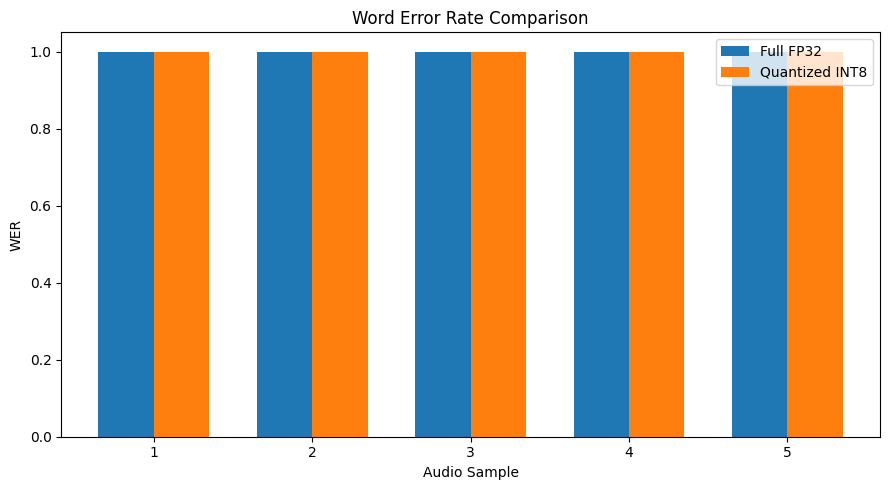

In [21]:
x = np.arange(len(comparison))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width/2,
    comparison["full_WER"],
    width,
    label="Full FP32"
)

plt.bar(
    x + width/2,
    comparison["quant_WER"],
    width,
    label="Quantized INT8"
)

plt.xlabel("Audio Sample")
plt.ylabel("WER")
plt.title("Word Error Rate Comparison")
plt.xticks(x, comparison["sample"])
plt.legend()
plt.tight_layout()
plt.show()

## 23. CER Graph

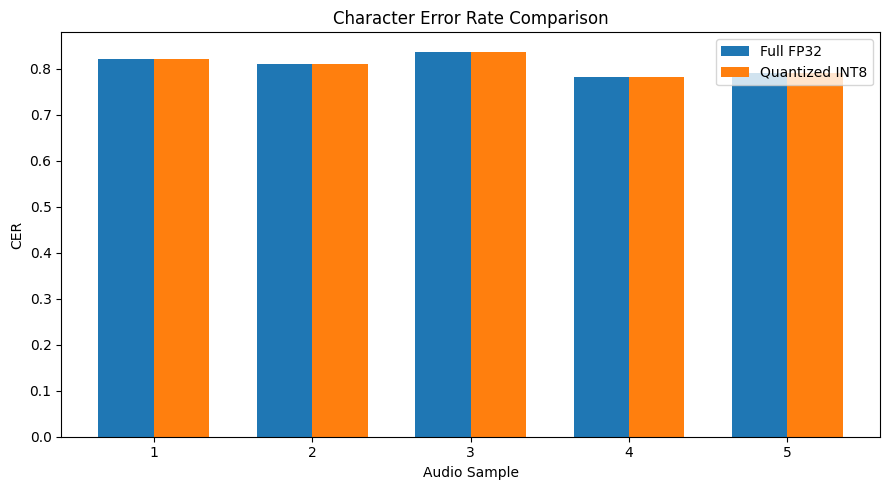

In [22]:
plt.figure(figsize=(9, 5))

plt.bar(
    x - width/2,
    comparison["full_CER"],
    width,
    label="Full FP32"
)

plt.bar(
    x + width/2,
    comparison["quant_CER"],
    width,
    label="Quantized INT8"
)

plt.xlabel("Audio Sample")
plt.ylabel("CER")
plt.title("Character Error Rate Comparison")
plt.xticks(x, comparison["sample"])
plt.legend()
plt.tight_layout()
plt.show()

## 24. Inference Time Graph

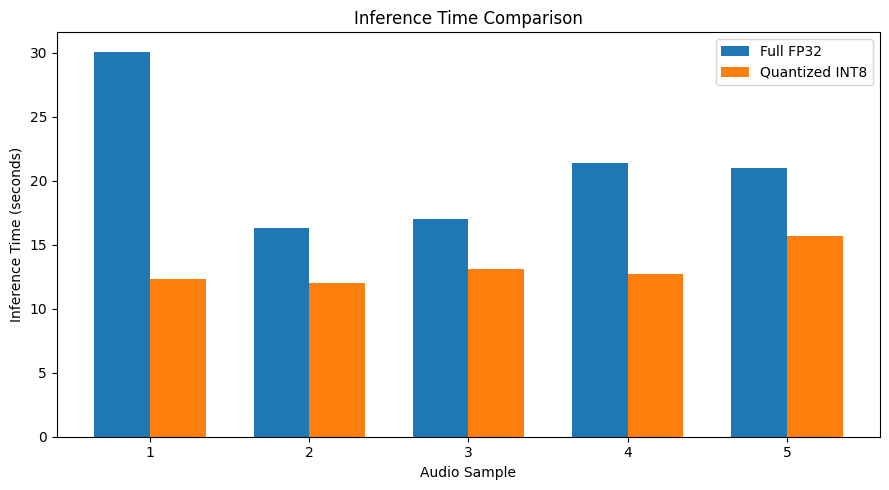

In [23]:
plt.figure(figsize=(9, 5))

plt.bar(
    x - width/2,
    comparison["full_time"],
    width,
    label="Full FP32"
)

plt.bar(
    x + width/2,
    comparison["quant_time"],
    width,
    label="Quantized INT8"
)

plt.xlabel("Audio Sample")
plt.ylabel("Inference Time (seconds)")
plt.title("Inference Time Comparison")
plt.xticks(x, comparison["sample"])
plt.legend()
plt.tight_layout()
plt.show()

## 25. Model Size Graph

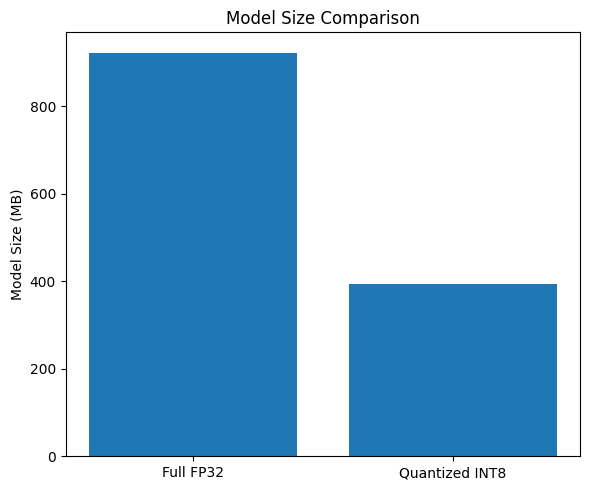

In [24]:
plt.figure(figsize=(6, 5))

plt.bar(
    ["Full FP32", "Quantized INT8"],
    [full_size, quant_size]
)

plt.ylabel("Model Size (MB)")
plt.title("Model Size Comparison")
plt.tight_layout()
plt.show()

# 26. Short Report

## Model Name and Source

**Whisper Small — `openai/whisper-small`**

The model is an open-source automatic speech recognition model available from Hugging Face.

## Reason for Selection

Whisper Small was selected because it provides a strong ASR baseline, supports multiple languages, is easy to use with Hugging Face Transformers, and allows a meaningful full-vs-quantized comparison.

## Dataset

**LibriSpeech ASR Dummy — `sanchit-gandhi/librispeech_asr_dummy`**

The dataset contains speech audio together with reference transcriptions.

## Full Model Configuration

- Model: Whisper Small
- Precision: FP32
- Device: CPU
- Sampling rate: 16 kHz
- Decoder: Whisper generation

## Quantized Model Configuration

- Model: Whisper Small
- Quantization: Dynamic INT8
- Quantized layers: supported Linear layers
- Device: CPU
- No retraining

## Audio Preprocessing

The audio was converted to the required 16 kHz sampling rate and passed through the Whisper processor to generate the model input features.

## Evaluation Metrics

The models were evaluated using:

- Word Error Rate
- Character Error Rate
- Inference time
- Model size
- Example transcription errors

## Conclusion

The FP32 model provides the baseline transcription quality. The INT8 model uses lower-precision parameters for supported layers, reducing the memory/storage requirements and potentially improving CPU efficiency.

The final WER and CER values determine how much transcription quality is lost, while model size and inference time determine the efficiency benefit.

If the INT8 WER/CER remains close to FP32 while model size and/or runtime decrease, INT8 quantization provides a favorable accuracy-efficiency trade-off.



# 28. References

1. Hugging Face, OpenAI Whisper Small model card: https://huggingface.co/openai/whisper-small
2. Hugging Face, LibriSpeech ASR Dummy dataset: https://huggingface.co/datasets/sanchit-gandhi/librispeech_asr_dummy
3. A. Radford et al., “Robust Speech Recognition via Large-Scale Weak Supervision,” 2022.
4. Hugging Face Transformers documentation.
5. JiWER documentation for WER and CER.